In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


In [2]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor

def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0

    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정

        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.

    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정

    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산

    return eval_loss, pred

def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [3]:
# data loading
from torchvision import datasets
from torchvision.transforms import ToTensor

train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=ToTensor())

print(train_dataset.data.shape)
print(test_dataset.data.shape)
print(np.array(train_dataset.targets).shape)
print(np.array(test_dataset.targets).shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000,)
(10000,)


Class = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


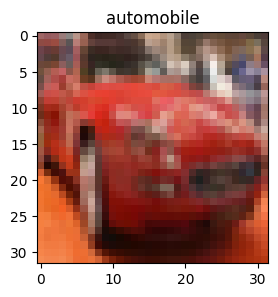

In [4]:
print('Class =', train_dataset.classes)

plt.figure(figsize=(3,3))
image, label = train_dataset.data[5], train_dataset.targets[5]
plt.imshow(image)
plt.title(train_dataset.classes[label])
plt.show()

In [5]:
# data 준비
train_loader = DataLoader(train_dataset, batch_size=64)

x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]
x_val = x_val/255
x_test = x_test/255
print('Original Shape=', x_val.shape, x_test.shape)

###################################################
# 차원 위치조정
# Original tensor : 건수, 세로픽셀, 가로픽셀, 채널
# 이미지 모델용 tensor : 건수, 채널, 세로픽셀, 가로픽셀
###################################################
x_val = x_val.transpose((0,3,1,2))
x_test = x_test.transpose((0,3,1,2))
print('Transforsed Shape=', x_val.shape, x_test.shape)

# Tensor 변환
x_val = torch.tensor(x_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

Original Shape= (5000, 32, 32, 3) (5000, 32, 32, 3)
Transforsed Shape= (5000, 3, 32, 32) (5000, 3, 32, 32)


In [6]:
# modeling
class CNN_model3(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(64*8*8, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.flatten(x)
    x = self.relu(self.fc1(x))
    x = self.fc2(x)
    return x

In [7]:
model = CNN_model3().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

Epoch 1, train loss : 1.5409, val loss : 1.2316
Epoch 2, train loss : 1.1498, val loss : 1.0424
Epoch 3, train loss : 0.9936, val loss : 0.9540
Epoch 4, train loss : 0.8920, val loss : 0.9229
Epoch 5, train loss : 0.8144, val loss : 0.9166
Epoch 6, train loss : 0.7486, val loss : 0.9236
Epoch 7, train loss : 0.6898, val loss : 0.9428
Epoch 8, train loss : 0.6349, val loss : 0.9735
Epoch 9, train loss : 0.5832, val loss : 0.9840
Epoch 10, train loss : 0.5359, val loss : 1.0128


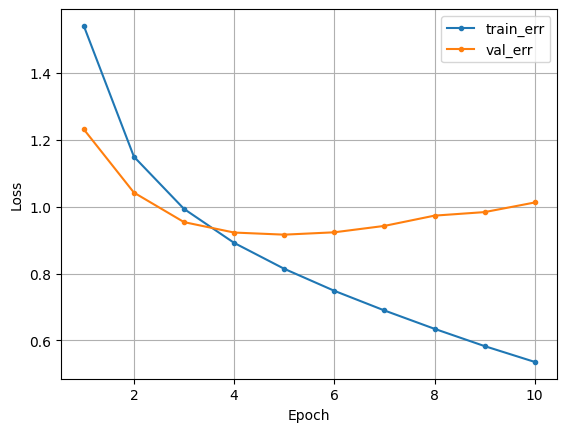

              precision    recall  f1-score   support

           0     0.7812    0.7324    0.7560       512
           1     0.8486    0.6909    0.7617       495
           2     0.6517    0.5061    0.5698       488
           3     0.4610    0.5646    0.5076       503
           4     0.6058    0.6734    0.6378       493
           5     0.6172    0.5605    0.5875       512
           6     0.7114    0.7505    0.7304       509
           7     0.7251    0.7941    0.7580       505
           8     0.8101    0.7742    0.7918       496
           9     0.7174    0.8029    0.7578       487

    accuracy                         0.6850      5000
   macro avg     0.6930    0.6850    0.6858      5000
weighted avg     0.6928    0.6850    0.6858      5000



In [8]:
# 학습
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

# learning curve
dl_learning_curve(tr_loss_list, val_loss_list)

# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# 평가
print(classification_report(y_test.numpy(), pred, digits = 4))